**Cell 1 — Imports and configuration**

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

TICKERS = {
    "Siemens":    {"file": "SIE_DE_price_volume.csv",  "color": "blue",  "linestyle": "-"},
    "Bayer":      {"file": "BAYN_DE_price_volume.csv", "color": "black", "linestyle": "--"},
    "BMW":        {"file": "BMW_DE_price_volume.csv",  "color": "red",   "linestyle": ":"},
    "Volkswagen": {"file": "VOW_DE_price_volume.csv",  "color": "green", "linestyle": "-."},
}

**Cell 2 — Load and align closing prices**

In [2]:
def load_close_series(filename):
    path = os.path.join(DATA_DIR, filename)
    s = pd.read_csv(path, parse_dates=["Date"]).set_index("Date")["Close"]
    s.index = pd.to_datetime(s.index, format="%d.%m.%Y")
    return s

prices = pd.concat(
    {name: load_close_series(cfg["file"]) for name, cfg in TICKERS.items()},
    axis=1,
)
prices = prices.dropna()

n = len(prices)
x = range(n)

**Cell 3 — Plot**

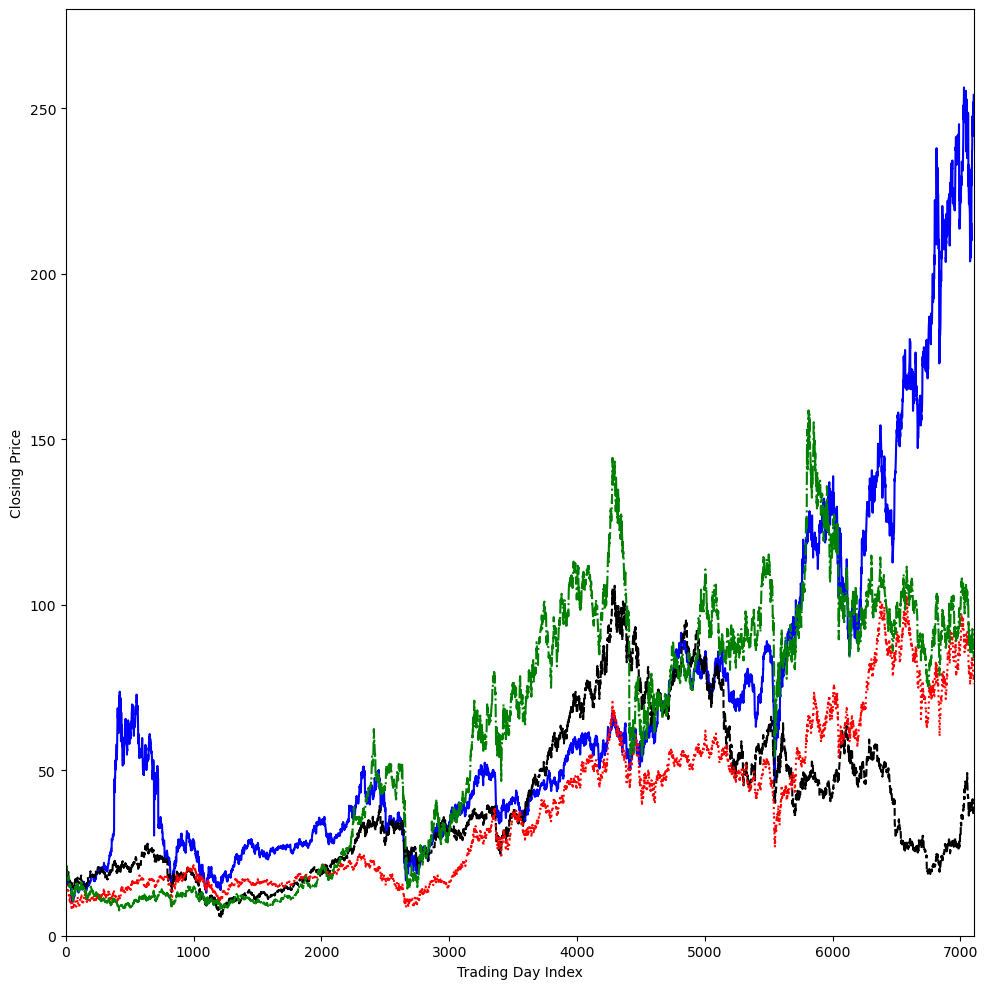

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

for name, cfg in TICKERS.items():
    ax.plot(
        x, prices[name].values,
        color=cfg["color"], linestyle=cfg["linestyle"],
        linewidth=1.5, label=name,
    )

ax.set_xlim(0, n - 1)
ax.set_ylim(0, 280)
ax.set_xlabel("Trading Day Index")
ax.set_ylabel("Closing Price")
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "closing_prices.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()